In [17]:
!pip install -q catboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from catboost import CatBoostClassifier, Pool
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [18]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

# Быстрая очистка
df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("Пропусков после очистки:", df.isnull().sum().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Данные загружены: 7043 строк, 20 столбцов
Пропусков после очистки: 0


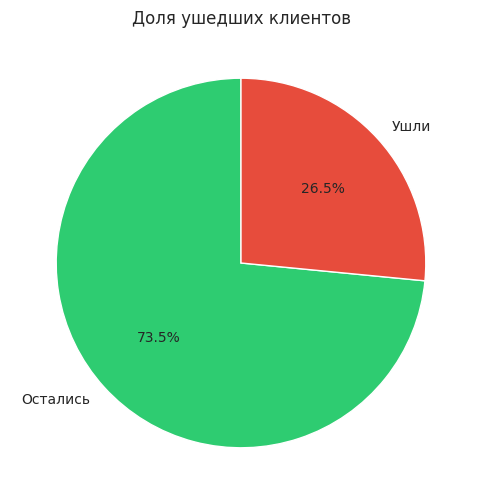

Ушли: 1869 (26.5%)


In [19]:
plt.figure(figsize=(6,6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Остались', 'Ушли'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Доля ушедших клиентов')
plt.show()
print(f"Ушли: {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")

0:	test: 0.7948113	best: 0.7948113 (0)	total: 92.1ms	remaining: 27.5s
100:	test: 0.8436074	best: 0.8445788 (62)	total: 4.59s	remaining: 9.05s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8445787801
bestIteration = 62

Shrink model to first 63 iterations.


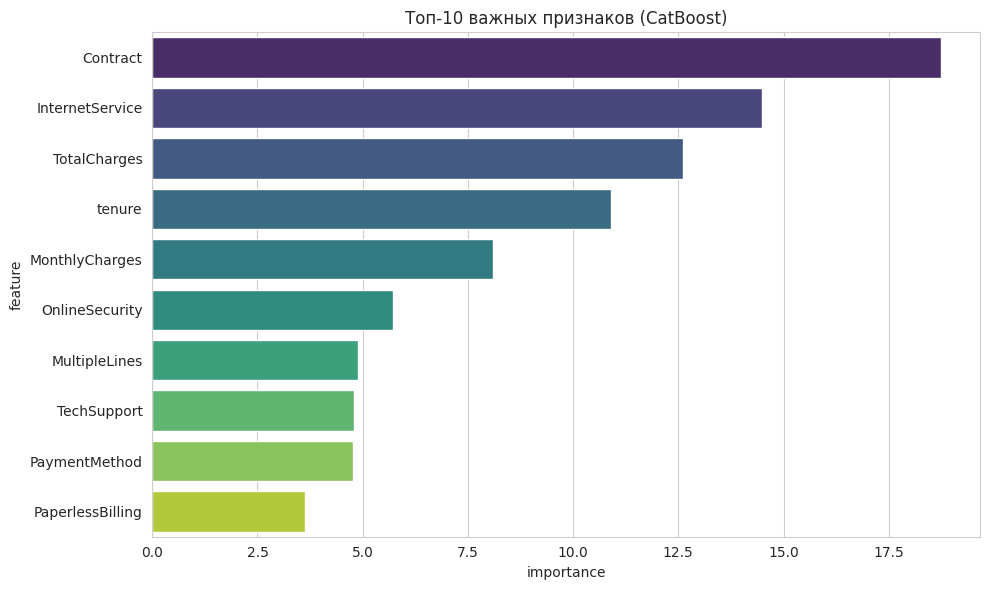

In [25]:
# Ячейка 4 – Подготовка данных и обучение CatBoost
X = df.drop('Churn', axis=1)
y = df['Churn']
cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)
model.fit(train_pool, eval_set=test_pool)

# Важность признаков (столбчатая диаграмма)
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances.head(10), palette='viridis')
plt.title('Топ-10 важных признаков (CatBoost)')
plt.tight_layout()
plt.show()

Accuracy: 0.8105
Precision: 0.6814
Recall: 0.5374
F1-score: 0.6009
ROC-AUC: 0.8446


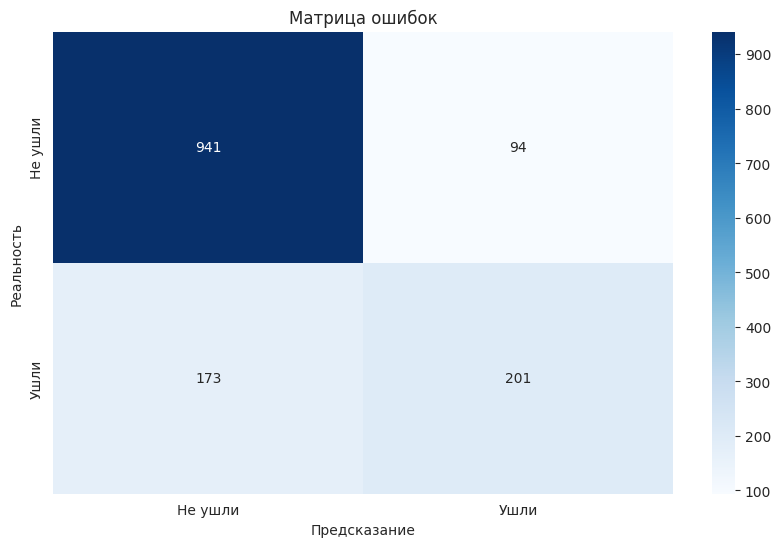

In [21]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

# Матрица ошибок (компактная)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Не ушли', 'Ушли'],
            yticklabels=['Не ушли', 'Ушли'])
plt.title('Матрица ошибок')
plt.ylabel('Реальность')
plt.xlabel('Предсказание')
plt.show()

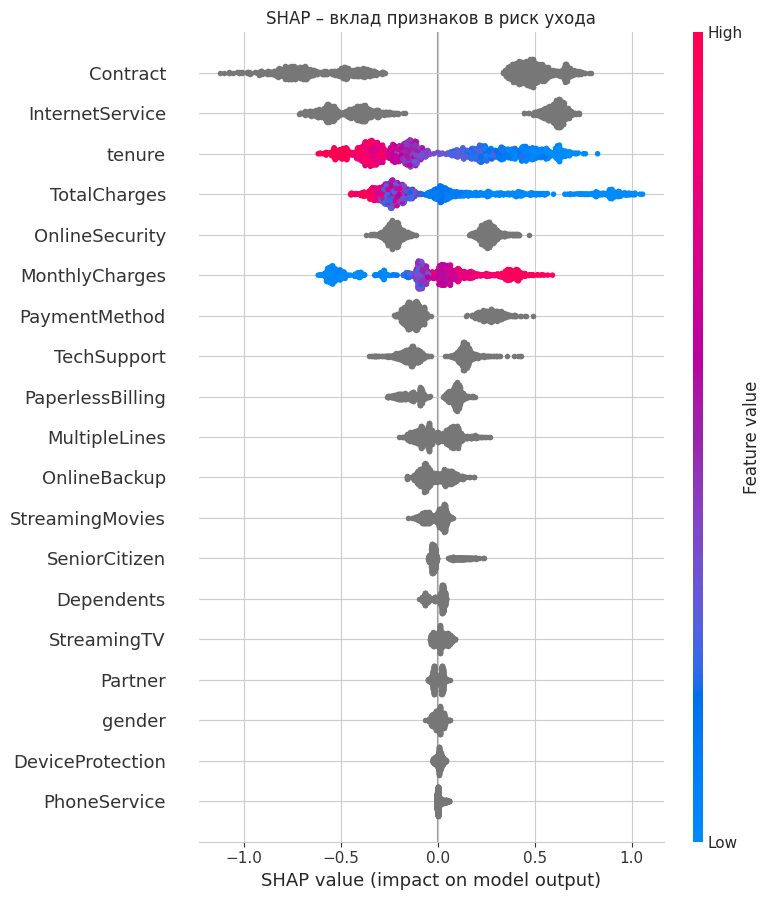

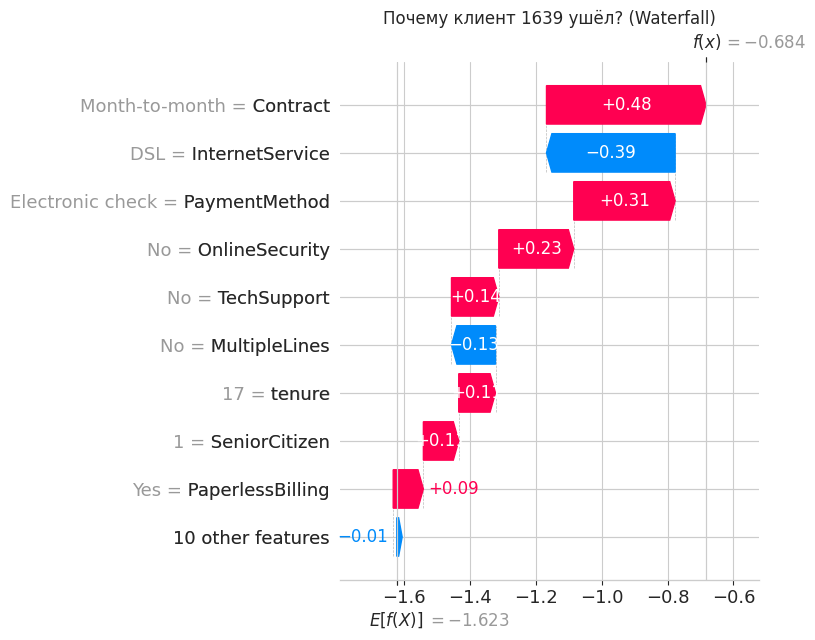

In [22]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot – глобальная интерпретация
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP – вклад признаков в риск ухода')
plt.tight_layout()
plt.show()

# Один пример – клиент, который ушёл
churn_idx = y_test[y_test == 1].index[0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[X_test.index.get_loc(churn_idx)],
        base_values=explainer.expected_value,
        data=X_test.loc[churn_idx].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title(f'Почему клиент {churn_idx} ушёл? (Waterfall)')
plt.tight_layout()
plt.show()